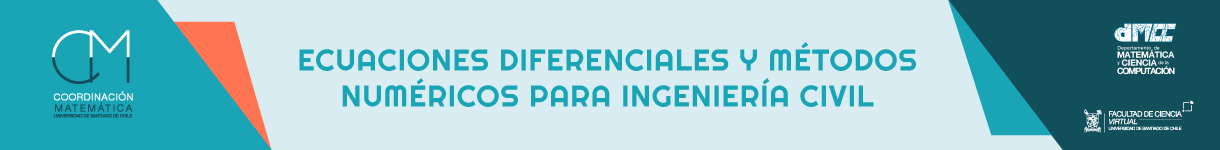


# **Semana 6**

- Descomposición en fracciones parciales
- Transformada de Laplace
- Función escalón unitario
- Transformada de Laplace inversa

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex='mathjax')

# Descomposición en fracciones parciales:

El comando `apart()` nos permite descomponer una expresión racional en fracciones parciales.

Por ejemplo, realicemos la descomposición en fracciones parciales de:

$$\frac{1-2s}{s^2-1}$$

In [2]:
x=sp.Symbol("x",real=True)
sp.apart((1-2*x)/(x**2-1))

      3           1    
- ───────── - ─────────
  2⋅(x + 1)   2⋅(x - 1)

Y podemos comprobar realizando la resta entre la expresión a descomponer y la descomposición:

In [3]:
sp.simplify((1-2*x)/(x**2-1)-sp.apart((1-2*x)/(x**2-1)))          #Recordemos que el comando simplify nos permite reducir expresiones simbólicamente

0

**Recuerdo:**

Sea $f:[0,\infty[ \rightarrow \mathbb{R}$ una función. La Transformada de Laplace de $f$ denotada por $\hat{F}$, $\hat{f}$, $F$ o $\mathcal{L}\{f\}$ es definida para todos aquellos valores $s$ donde la integral $$\hat{F}(s)=\int_{0}^\infty f(t)e^{-st} dt$$ es convergente.

En Python, este cálculo lo podríamos realizar por definición o utilizando la función llamada `laplace_transform`, que lo hace de una manera más eficiente y utilizando técnicas más avanzadas que solo integrar, que además retorna las condiciones de convergencia.

# Ejemplo: Cálculo por definición

Consideremos la función $f(t)=t^3$ con $t\geq 0$, su transformada de Laplace viene dada para $s$ por $$\hat{F}(s)=\int_{0}^\infty t^3 e^{-st} dt$$ si dicha integral es convergente.

Claramente, si $s\leq 0$ la integral diverge. Por lo tanto, para $s>0$ se tiene que:

In [4]:
t=sp.Symbol("t",real=True)
s=sp.Symbol("s",real=True, positive=True)
sp.integrate(t**3*sp.exp(-s*t),(t,0,sp.oo))

6 
──
 4
s 

En este caso, como se mencionó, el cálculo de la transformada por integración directa no nos dice las condiciones de convergencia.

Realicemos el mismo cálculo utilizando la función `laplace_transform` de la librería `sympy`:

In [5]:
sp.laplace_transform(t**3,t,s)              #Recibe como parámetros la expresión de f, la variable independiente t, la variable en que quedará la transformada (s)

⎛6          ⎞
⎜──, 0, True⎟
⎜ 4         ⎟
⎝s          ⎠

En este caso retorna $ \left(\frac{6}{s^4},0,True\right)$, donde la primera coordenada es la transformada de la expresión, 0 representa que "$s>0$" y "True" que la transformación fue exitosa.

En el caso de querer realizar el cálculo de la Transformada de Laplace sin retornar las condiciones de convergencia, podemos agregar el parámetro `noconds=True`:

In [6]:
sp.laplace_transform(t**3,t,s,noconds=True)

6 
──
 4
s 

Calculemos la transformada de $f(t)=e^{3t}$ y obtengamos sus condiciones de convergencia para $s$:

In [7]:
f=sp.exp(3*t)
sp.laplace_transform(f,t,s)

⎛  1           ⎞
⎜─────, 3, True⎟
⎝s - 3         ⎠

# Ejemplo:

Realicemos el cálculo de las tranformadas de Laplace mediante `laplace_transform` de:
- $f(t)=cos(t)$
- $f(t)=cosh(2t)$

In [8]:
f=sp.cos(t)
sp.laplace_transform(f,t,s,noconds=True)

  s   
──────
 2    
s  + 1

In [9]:
f=sp.cos(t)
sp.laplace_transform(f,t,s)

⎛  s            ⎞
⎜──────, 0, True⎟
⎜ 2             ⎟
⎝s  + 1         ⎠

In [10]:
g=sp.cosh(2*t)
sp.laplace_transform(g,t,s,noconds=True)

  s   
──────
 2    
s  - 4

In [11]:
g=sp.cosh(2*t)
sp.laplace_transform(g,t,s)

⎛  s            ⎞
⎜──────, 2, True⎟
⎜ 2             ⎟
⎝s  - 4         ⎠

# Ejemplo: Tabla de transformadas

In [12]:
omega = sp.Symbol('omega', real=True)
t, s = sp.symbols('t, s')
a = sp.symbols('a', real=True, positive=True)

exp = sp.exp
sen = sp.sin
cos = sp.cos
funciones = [
  1,
  t,
  exp(-a*t),
  t*exp(-a*t),
  t**2*exp(-a*t),
  sen(omega*t),
  cos(omega*t),
  1 - exp(-a*t),
  exp(-a*t)*sen(omega*t),
  exp(-a*t)*cos(omega*t),
]
funciones

⎡       -a⋅t     -a⋅t   2  -a⋅t                           -a⋅t   -a⋅t          ↪
⎣1, t, ℯ    , t⋅ℯ    , t ⋅ℯ    , sin(ω⋅t), cos(ω⋅t), 1 - ℯ    , ℯ    ⋅sin(ω⋅t) ↪

↪    -a⋅t         ⎤
↪ , ℯ    ⋅cos(ω⋅t)⎦

In [13]:
F = [sp.laplace_transform(f,t,s,noconds=True) for f in funciones]
F

⎡1  1     1       1         2         ω        s         1     1        ω      ↪
⎢─, ──, ─────, ────────, ────────, ───────, ───────, - ───── + ─, ──────────── ↪
⎢s   2  a + s         2         3   2    2   2    2    a + s   s   2           ↪
⎣   s          (a + s)   (a + s)   ω  + s   ω  + s                ω  + (a + s) ↪

↪        a + s    ⎤
↪ ─, ─────────────⎥
↪ 2   2          2⎥
↪    ω  + (a + s) ⎦

# **Transformada inversa**

En la resolución de ecuaciones diferenciales mediante transformada de Laplace, estaremos interesados en conocer la transformada inversa de una función transformada en $s$ dada.

Es decir, dada $\hat{F}(s)$ encontrar $f(t)$. Esto lo podemos hacer mediante el comando `inverse_laplace_transform` de la librería `sympy`.

# Ejemplo:

Calculemos la transformada inversa de la siguiente expresión:
$$\hat{F}(s)=\frac{1}{s}$$
y comprobemos que corresponde a $f(t)=1$.

In [14]:
s=sp.Symbol("s",real=True)
F=1/s
sp.inverse_laplace_transform(F,s,t,noconds=True)

θ(t)

En este caso retorna una función simbolizada por $\theta (t)$. Dicha función es conocida como heaviside o escalón unitario.

Corresponde a la siguiente función:
$$\theta(t) = \left\lbrace
\begin{matrix}
0 & si & t\leq 0 \\
1 & si & 0<t
\end{matrix}
\right.$$

Graficamente:

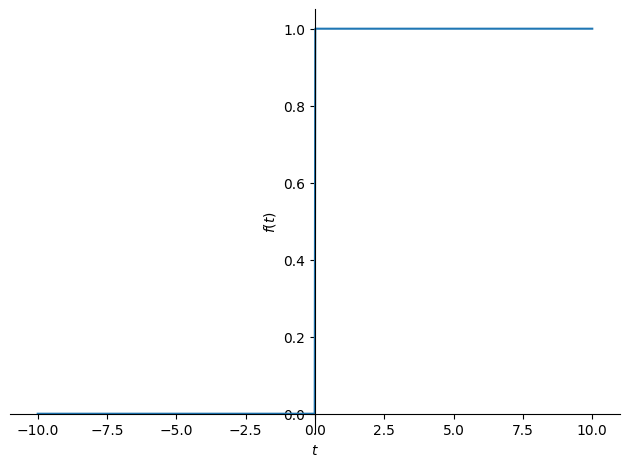

In [ ]:
sp.plot(sp.Heaviside(t))

Lo que es coherente con la transformada de Laplace, pues recordemos que la función $f:[0,\infty[\longrightarrow \mathbb{R}$ tal que $f(t)=1$ es justamente $\theta_{|_{[0,\infty[}}(t)$.

# Ejemplo:

Calculemos la transformada de
$$f(t)=e^{-\alpha t}$$

 con $\alpha \in \mathbb{R}^+$. Luego, compruebe calculando la transformada inversa de la transformada calculada.

In [16]:
a=sp.Symbol("alpha",real=True,positive=True)            #Definimos "a" como la constante alpha
a

α

In [17]:
f=sp.exp(-a*t)
F=sp.laplace_transform(f,t,s,noconds=True)
F

  1  
─────
α + s

In [18]:
sp.inverse_laplace_transform(F,s,t,noconds=True)

 -α⋅t     
ℯ    ⋅θ(t)

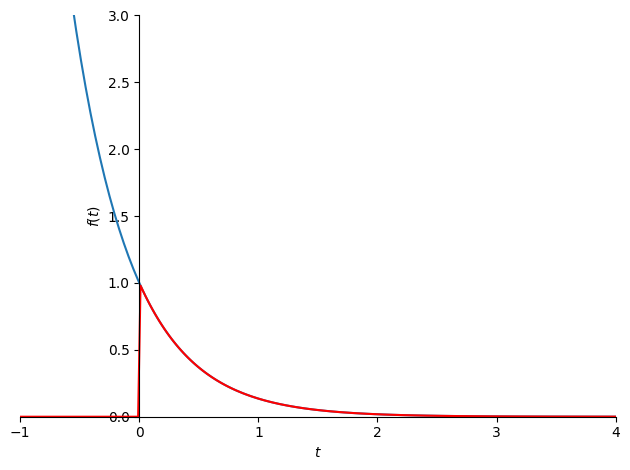

In [19]:
#Grafiquemos la función encontrada con alpha=2 solo para interpretar
f=sp.exp(-a*t)
p = sp.plot(f.subs({a: 2}),sp.inverse_laplace_transform(F,s,t).subs({a: 2}),
xlim=(-1, 4), ylim=(0, 3), show=False)
p[1].line_color = 'red'
p.show()

Nuevamente, como aparece la función $\theta $ debemos interpretar que la transformada inversa en este caso es:

$$f(t) = \left\lbrace
\begin{matrix}
0 & si & t\leq 0 \\
e^{-\alpha t} & si & 0<t
\end{matrix}
\right.$$

# Ejercicio 1:

Calcular la transformada de Laplace de
$$ g(t) = \cos At + \sin Bt, $$
con $A,B \in \mathbb{R}$

In [20]:
A = sp.Symbol("A",real=True,positive=True)            #Definimos "A" como la constante A
B = sp.Symbol("B",real=True,positive=True)            #Definimos "B" como la constante B
g = sp.cos(A*t)+sp.sin(B*t)
G = sp.laplace_transform(g,t,s,noconds=True)
G

   B         s   
─────── + ───────
 2    2    2    2
B  + s    A  + s 

# Ejercicio 2:

Suponga que $f:[0,\infty[ \to \mathbb{R}$ es continua por partes y de orden exponencial (posee transformada de Laplace). Verifique que:

$$\mathcal{L}\lbrace t f(t) \rbrace (s) = -\dfrac{d}{ds}\left[ \hat{F}(s) \right]$$

para las funciones:

* $f(t)=t^3 $

* $f(t)=5sen(2t)$

* $f(t)=7cos(5t)-e^{-3t}+5$

En caso de ser necesario, utilice `sp.simplify` para simplificar una expresión o verificar que dos expresiones son iguales.

In [ ]:
t, s= sp.symbols('t, s')
f1 = t**3
f2  = 5 * sp.sin(2*t)
f3 = 7 * sp.cos(5*t) - sp.exp(-3*t) + 5

dltf1 = -sp.laplace_transform(f1,t,s,noconds=True).diff(s)
dltf2 = -sp.laplace_transform(f2,t,s,noconds=True).diff(s)
dltf3 = -sp.laplace_transform(f3,t,s,noconds=True).diff(s)

ltf1 = sp.laplace_transform(t*f1,t,s,noconds=True)
ltf2 = sp.laplace_transform(t*f2,t,s,noconds=True)
ltf3 = sp.laplace_transform(t*f3,t,s,noconds=True)

resultado = sp.simplify(dltf1 - ltf1), sp.simplify(dltf2 - ltf2), sp.simplify(dltf3 - ltf3)
resultado

(0, 0, 0)

# Ejercicio 3:

Utilizando el teorema que, bajo ciertas condiciones, establece que

$$ \mathcal{L} \left\lbrace t^n f(t) \right\rbrace (s) = (-1)^{n} \frac{d^n}{ds^n} \hat{F}(s)  $$

Calcule la transformada de Laplace de:

* $g(t)= t^{2} \sin(4t)$
* $g(t)=t^{7} e^{-2t}\cos t$
* $g(t)=t^{4} e^{-4t}\cos t \sin (2t)$

In [39]:
t, s= sp.symbols('t, s')
g1 =  sp.sin(4*t)
g2  = sp.exp(-2*t) * sp.cos(t)
g3 =  sp.cos(t) * sp.sin(2*t) * sp.exp(-4*t)

dltg1 = (-1)**2 * sp.laplace_transform(g1,t,s,noconds=True).diff(s, 2)
dltg2 = (-1)**7 * sp.laplace_transform(g2,t,s,noconds=True).diff(s, 7)
dltg3 = (-1)**4 * sp.laplace_transform(g3,t,s,noconds=True).diff(s, 4)
display(g1, g2, g3)

ltg1 = sp.laplace_transform(t**2 *g1,t,s,noconds=True)
ltg2 = sp.laplace_transform(t**7 *g2,t,s,noconds=True)
ltg3 = sp.laplace_transform(t**4 *g3,t,s,noconds=True)
display(ltg1, ltg2, ltg3)

resultado = sp.simplify(dltg1 - ltg1), sp.simplify(dltg2 - ltg2), sp.simplify(dltg3 - ltg3)
resultado

sin(4⋅t)

 -2⋅t       
ℯ    ⋅cos(t)

 -4⋅t                
ℯ    ⋅sin(2⋅t)⋅cos(t)

    ⅈ            ⅈ     
────────── - ──────────
         3            3
(s + 4⋅ⅈ)    (s - 4⋅ⅈ) 

    2520           2520    
──────────── + ────────────
           8              8
(s + 2 + ⅈ)    (s + 2 - ⅈ) 

     6⋅ⅈ             6⋅ⅈ            6⋅ⅈ             6⋅ⅈ      
────────────── + ──────────── - ──────────── - ──────────────
             5              5              5                5
(s + 4 + 3⋅ⅈ)    (s + 4 + ⅈ)    (s + 4 - ⅈ)    (s + 4 - 3⋅ⅈ) 

(0, 0, 0)

# Ejercicio 4:

Utilizando el teorema que, bajo ciertas condiciones, establece que

$$ \mathcal{L} \left\lbrace e^{at} f(t) \right\rbrace (s) = \hat{F}(s-a)  $$

Calcule la transformada de Laplace de:

* $f(t)= t^{2} \sin(4t)$
* $f(t)=t^{7} e^{-2t}\cos t$
* $f(t)=t^{4} e^{-4t}\cos t \sin (2t)$

In [42]:
t = sp.Symbol("t",real=True)
s = sp.Symbol("s",real=True, positive=True)

f1 = t**2 * sp.sin(4*t)
f2 = t**7 * sp.cos(t)
f3 = t**4 * sp.cos(t) * sp.sin(2*t)

ltf1 = sp.laplace_transform(f1,t,s,noconds=True)
ltf2 = sp.laplace_transform(f2,t,s,noconds=True)
ltf3 = sp.laplace_transform(f3,t,s,noconds=True)
display(ltf1, ltf2, ltf3)

mltf1 = sp.laplace_transform(f1,t,s,noconds=True)
mltf2 = sp.laplace_transform(sp.exp(-2*t)*f2,t,s,noconds=True)
mltf3 = sp.laplace_transform(sp.exp(-4*t)*f3,t,s,noconds=True)

resultado = ltf1.subs(s, s) - mltf1, ltf2.subs(s, s + 2) - mltf2, ltf3.subs(s, s + 4) - mltf3
resultado

    ⅈ            ⅈ     
────────── - ──────────
         3            3
(s + 4⋅ⅈ)    (s - 4⋅ⅈ) 

  2520       2520  
──────── + ────────
       8          8
(s + ⅈ)    (s - ⅈ) 

   6⋅ⅈ         6⋅ⅈ        6⋅ⅈ         6⋅ⅈ    
────────── + ──────── - ──────── - ──────────
         5          5          5            5
(s + 3⋅ⅈ)    (s + ⅈ)    (s - ⅈ)    (s - 3⋅ⅈ) 

(0, 0, 0)

# Ejercicio 5:

Determinar la transformada inversa de las siguientes funciones:

* $\hat{F}(s)=\frac{2s-8}{s^2-5s+6}$
* $\hat{F}(s)=\frac{s+1}{s^2-4s}$
* $\hat{F}(s)=\frac{s+1}{s^2+2}$
* $\hat{F}(s)=\frac{10}{(s+2)(s^2+6s+13)}+\frac{3s+5}{s^2+6s+13}$

Luego, separe en fracciones parciales las transformadas propuestas y determine las transformadas inversas usando linealidad.

In [47]:
F1 = sp.apart((2*s - 8)/(s**2 - 5*s + 6))
F2 = sp.apart((s + 1)/(s**2 - 4*s))
F3 = sp.apart((s + 1)/(s**2 + 2))
F4 = sp.apart((10)/((s + 2)*(s**2 + 6*s + 13)) + (3*s + 5)/(s**2 + 6*s + 13))
lista  = [F1, F2, F3, F4]
resultado = [sp.inverse_laplace_transform(F,s,t,noconds=True) for F in lista]
resultado

⎡                                4⋅t                                           ↪
⎢     3⋅t           2⋅t       5⋅ℯ   ⋅θ(t)   θ(t)  ⎛√2⋅sin(√2⋅t)            ⎞   ↪
⎢- 2⋅ℯ   ⋅θ(t) + 4⋅ℯ   ⋅θ(t), ─────────── - ────, ⎜──────────── + cos(√2⋅t)⎟⋅θ ↪
⎣                                  4         4    ⎝     2                  ⎠   ↪

↪                                                               ⎤
↪      ⎛     -3⋅t             -3⋅t         ⎞           -2⋅t     ⎥
↪ (t), ⎝- 3⋅ℯ    ⋅sin(2⋅t) + ℯ    ⋅cos(2⋅t)⎠⋅θ(t) + 2⋅ℯ    ⋅θ(t)⎥
↪                                                               ⎦

# Ejercicio 6:

Usando la transformada de Laplace y transformada inversa compruebe simbólicamente que:

$$\mathcal{L}\left( e^{2t}(t-1)^2\right)(s)=\frac{2}{(s-2)^3}-\frac{2}{(s-2)^2}+\frac{1}{s-2}$$

In [48]:
t = sp.Symbol("t",real=True)
s = sp.Symbol("s",real=True, positive=True)

f = sp.exp(2*t) * (t - 1)**2
F = sp.apart(sp.laplace_transform(f,t,s,noconds=True))
F

  1        2          2    
───── - ──────── + ────────
s - 2          2          3
        (s - 2)    (s - 2) 